<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 5</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Reza Pirhadi <br>
        <b>🆔 Student ID:</b> 810102423 <br><br>
        <h5 style="color: #1a365d;"> TASK 1 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
        This notebook contains the programmatic implementation for Assignment 5 - Task 1. It focuses on predicting Formula 1 pit stop strategies using historical race datasets. The implementation covers a complete machine learning pipeline, including feature engineering, class imbalance handling, training classification baselines, and implementing Semi-Supervised Pseudo-Labeling and Active Learning Uncertainty Sampling loops to iteratively leverage unlabeled data.
</div>

## Table of Contents
1. [Exploratory Data Analysis (EDA) & Feature Engineering](#eda-preprocessing)
2. [Baseline Supervised Models & Class Imbalance Handling](#baselines)
3. [Semi-Supervised Learning (Pseudo-Labeling Loop)](#ssl-pseudo-labeling)
4. [Active Learning & Uncertainty Query Strategies](#active-learning)
5. [Evaluation, Strategy Comparison & Trade-off Analysis](#evaluation)

<a id="eda-preprocessing"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Exploratory Data Analysis (EDA) & Feature Engineering</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd2a20; color: #c02121;">
    <strong>🚗 Methodology:</strong>
    This phase involves parsing historical F1 CSV files, performing statistical checks on race features, and engineering status-driven attributes (such as tire degradation cycles and relative gaps). To prevent data leakage, <code>safety_car_likely</code> and <code>stop_duration_ms</code> are dropped. Numerical variables are scaled using <code>StandardScaler</code>, categorical dimensions are encoded, and the data is stratified into an <strong>80/10/10</strong> train/validation/test split.
</div>


In [117]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from scipy.stats import ks_2samp, entropy
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder,label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score ,f1_score, accuracy_score, precision_score
from itertools import cycle
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

In [118]:
def load_and_engineer_features_strict(base_path='./data/task1'):
    print("--- 1.1 Download and Inspect ---")
    races = pd.read_csv(os.path.join(base_path, 'races.csv'))
    pit_stops = pd.read_csv(os.path.join(base_path, 'pit_stops.csv'))
    lap_times = pd.read_csv(os.path.join(base_path, 'lap_times.csv'))
    results = pd.read_csv(os.path.join(base_path, 'results.csv')) 
    constructors = pd.read_csv(os.path.join(base_path, 'constructors.csv')) 
    circuits = pd.read_csv(os.path.join(base_path, 'circuits.csv')) 
    driver_standings = pd.read_csv(os.path.join(base_path, 'driver_standings.csv'))
    constructor_standings = pd.read_csv(os.path.join(base_path, 'constructor_standings.csv'))

    print("--- 1.2 Join the Tables ---")
    races = races[(races['year'] >= 2014) & (races['year'] <= 2024)]
    races = pd.merge(races, circuits[['circuitId', 'name']], on='circuitId', suffixes=('', '_circuit'))
    races.rename(columns={'name_circuit': 'circuit_name'}, inplace=True)

    pit_f = pit_stops.rename(columns={'lap': 'pit_lap', 'milliseconds': 'stop_duration_ms'})
    lap_times_renamed = lap_times.rename(columns={'milliseconds': 'lap_time_ms', 'position': 'race_position'})
    
    df = pd.merge(pit_f, races[['raceId', 'year', 'round', 'circuit_name']], on='raceId', how='inner')
    
    lap_pos = lap_times_renamed[['raceId', 'driverId', 'lap', 'race_position', 'lap_time_ms']].rename(columns={'lap': 'pit_lap'})
    df = pd.merge(df, lap_pos, on=['raceId', 'driverId', 'pit_lap'], how='inner')
    
    df = pd.merge(df, results[['raceId', 'driverId', 'constructorId', 'grid']], on=['raceId', 'driverId'], how='inner')
    df.rename(columns={'grid': 'grid_position'}, inplace=True)
    
    df = pd.merge(df, constructors[['constructorId', 'name']], on='constructorId')
    df.rename(columns={'name': 'constructor_name'}, inplace=True)

    races_sorted = races.sort_values(['year', 'round'])
    races_sorted['prev_raceId'] = races_sorted.groupby('year')['raceId'].shift(1)
    df = pd.merge(df, races_sorted[['raceId', 'prev_raceId']], on='raceId', how='left')
    
    prev_driver_standings = driver_standings[['raceId', 'driverId', 'points']].rename(columns={'raceId': 'prev_raceId', 'points': 'driver_champ_points'})
    df = pd.merge(df, prev_driver_standings, on=['prev_raceId', 'driverId'], how='left').fillna({'driver_champ_points': 0})
    
    prev_const_standings = constructor_standings[['raceId', 'constructorId', 'points']].rename(columns={'raceId': 'prev_raceId', 'points': 'constructor_champ_points'})
    df = pd.merge(df, prev_const_standings, on=['prev_raceId', 'constructorId'], how='left').fillna({'constructor_champ_points': 0})
    df.drop(columns=['prev_raceId'], inplace=True)

    print("--- 1.3 Engineer Lap Level Features ---")
    df = df.sort_values(by=['raceId', 'driverId', 'pit_lap'])

    personal_best = lap_times_renamed.groupby(['raceId', 'driverId'])['lap_time_ms'].min().reset_index(name='personal_best_ms')
    df = pd.merge(df, personal_best, on=['raceId', 'driverId'], how='left')
    df['lap_time_delta'] = (df['lap_time_ms'] - df['personal_best_ms']).clip(upper=100000)
    
    df['prev_pit_lap'] = df.groupby(['raceId', 'driverId'])['pit_lap'].shift(1).fillna(0).astype(int)
    df['laps_since_last_pit'] = df['pit_lap'] - df['prev_pit_lap']
    
    temp_lap_max = lap_times_renamed.groupby('raceId')['lap'].max().reset_index(name='max_lap')
    df = pd.merge(df, temp_lap_max, on='raceId', how='left')
    df['laps_remaining'] = df['max_lap'] - df['pit_lap']
    
    lap_f_sorted = lap_times_renamed.sort_values(['raceId', 'driverId', 'lap'])
    lap_f_sorted['cum_time_ms'] = lap_f_sorted.groupby(['raceId', 'driverId'])['lap_time_ms'].cumsum()
    pos_time = lap_f_sorted[['raceId', 'lap', 'race_position', 'cum_time_ms', 'driverId']].copy()
    
    df = pd.merge(df, lap_f_sorted[['raceId', 'driverId', 'lap', 'cum_time_ms']].rename(columns={'lap': 'pit_lap'}), on=['raceId', 'driverId', 'pit_lap'], how='left')
    
    ahead_lookup = pos_time.rename(columns={'race_position': 'pos_ahead_key', 'cum_time_ms': 'cum_time_ahead', 'lap': 'pit_lap', 'driverId': 'driverId_ahead'})
    df['pos_ahead_key'] = df['race_position'] - 1
    df = pd.merge(df, ahead_lookup[['raceId', 'pit_lap', 'pos_ahead_key', 'cum_time_ahead', 'driverId_ahead']], on=['raceId', 'pit_lap', 'pos_ahead_key'], how='left')
    df['approx_gap_ahead'] = ((df['cum_time_ms'] - df['cum_time_ahead']) / 1000.0).fillna(15.0).clip(lower=0, upper=15.0)
    
    behind_lookup = pos_time.rename(columns={'race_position': 'pos_behind_key', 'cum_time_ms': 'cum_time_behind', 'lap': 'pit_lap', 'driverId': 'driverId_behind'})
    df['pos_behind_key'] = df['race_position'] + 1
    df = pd.merge(df, behind_lookup[['raceId', 'pit_lap', 'pos_behind_key', 'cum_time_behind', 'driverId_behind']], on=['raceId', 'pit_lap', 'pos_behind_key'], how='left')
    df['approx_gap_behind'] = ((df['cum_time_behind'] - df['cum_time_ms']) / 1000.0).fillna(15.0).clip(lower=0, upper=15.0)

    print("    -> Calculating Safety Car & Degradation Slopes...")
    inlap = pit_f[['raceId', 'driverId', 'pit_lap']].rename(columns={'pit_lap': 'lap'})
    outlap = pit_f[['raceId', 'driverId', 'pit_lap']].copy()
    outlap['lap'] = outlap['pit_lap'] + 1
    pit_affected = pd.concat([inlap, outlap[['raceId', 'driverId', 'lap']]]).drop_duplicates()
    pit_affected['is_pit_affected'] = True

    lap_clean = pd.merge(lap_times_renamed, pit_affected, on=['raceId', 'driverId', 'lap'], how='left')
    
    lap_clean['is_pit_affected'] = lap_clean['is_pit_affected'].fillna(False).astype(bool)
    
    lap_clean = lap_clean[~lap_clean['is_pit_affected']]

    race_baseline = lap_clean.groupby('raceId')['lap_time_ms'].median().reset_index(name='baseline_lap_ms')
    lap_clean = pd.merge(lap_clean, race_baseline, on='raceId', how='left')
    lap_clean['is_slow'] = lap_clean['lap_time_ms'] > 1.25 * lap_clean['baseline_lap_ms']

    lap_flags = lap_clean.groupby(['raceId', 'lap']).agg(n_drivers=('driverId', 'nunique'), n_slow=('is_slow', 'sum')).reset_index()
    lap_flags['slow_frac'] = lap_flags['n_slow'] / lap_flags['n_drivers']
    lap_flags['safety_car_likely'] = ((lap_flags['n_slow'] >= 5) & (lap_flags['slow_frac'] >= 0.4)).astype(int)

    df = pd.merge(df, lap_flags[['raceId', 'lap', 'safety_car_likely']].rename(columns={'lap': 'pit_lap'}), on=['raceId', 'pit_lap'], how='left')
    df['safety_car_likely'] = df['safety_car_likely'].fillna(0).astype(int)

    t0 = time.time()
    lap_lookup = {k: v.sort_values('lap')[['lap', 'lap_time_ms']].to_numpy() for k, v in lap_times_renamed.groupby(['raceId', 'driverId'])}
    slopes = np.full(len(df), np.nan)
    
    for i, row in enumerate(df.itertuples()):
        arr = lap_lookup.get((row.raceId, row.driverId))
        if arr is None: continue
        lo = max(row.prev_pit_lap + 1, row.pit_lap - 4)
        pts = arr[(arr[:, 0] >= lo) & (arr[:, 0] <= row.pit_lap)]
        if len(pts) >= 2:
            slopes[i] = np.polyfit(pts[:, 0], pts[:, 1], 1)[0]
            
    df['tyre_deg_slope_ms_per_lap'] = np.clip(np.nan_to_num(slopes, nan=0.0), a_min=-5000, a_max=5000)
    
    recent1 = pit_f[['raceId', 'driverId', 'pit_lap']].copy()
    recent1['lap'] = recent1['pit_lap'] + 1
    recent2 = pit_f[['raceId', 'driverId', 'pit_lap']].copy()
    recent2['lap'] = recent2['pit_lap'] + 2
    recent_pit = pd.concat([recent1, recent2])[['raceId', 'driverId', 'lap']].drop_duplicates()
    recent_pit['recent_flag'] = 1

    df = pd.merge(df, recent_pit.rename(columns={'driverId': 'driverId_ahead', 'lap': 'pit_lap', 'recent_flag': 'rival_ahead_just_pitted'}), on=['raceId', 'driverId_ahead', 'pit_lap'], how='left')
    df['rival_ahead_just_pitted'] = df['rival_ahead_just_pitted'].fillna(0).astype(int)

    df = pd.merge(df, recent_pit.rename(columns={'driverId': 'driverId_behind', 'lap': 'pit_lap', 'recent_flag': 'rival_behind_just_pitted'}), on=['raceId', 'driverId_behind', 'pit_lap'], how='left')
    df['rival_behind_just_pitted'] = df['rival_behind_just_pitted'].fillna(0).astype(int)
    
    print(f"Final Dataset Shape: {df.shape}")
    return df

df_raw = load_and_engineer_features_strict(base_path='./data/task1')

print("--- Data Types ---")
print(df_raw.dtypes.head(10)) 

print("\n--- Missing Values ---")
missing = df_raw.isna().sum()
print(missing[missing > 0]) 

print("\n--- Data Head (First 3 Rows) ---")
display(df_raw.head(3))

--- 1.1 Download and Inspect ---
--- 1.2 Join the Tables ---
--- 1.3 Engineer Lap Level Features ---
    -> Calculating Safety Car & Degradation Slopes...
Final Dataset Shape: (8360, 36)
--- Data Types ---
raceId              int64
driverId            int64
stop                int64
pit_lap             int64
time                  str
duration              str
stop_duration_ms    int64
year                int64
round               int64
circuit_name          str
dtype: object

--- Missing Values ---
cum_time_ahead     514
driverId_ahead     514
cum_time_behind    594
driverId_behind    594
dtype: int64

--- Data Head (First 3 Rows) ---


,raceId,driverId,stop,pit_lap,time,duration,stop_duration_ms,year,round,circuit_name,...,driverId_ahead,approx_gap_ahead,pos_behind_key,cum_time_behind,driverId_behind,approx_gap_behind,safety_car_likely,tyre_deg_slope_ms_per_lap,rival_ahead_just_pitted,rival_behind_just_pitted
0,900,3,1,12,17:27:27,24.331,24331,2014,1,Albert Park Grand Prix Circuit,...,NaN,15.000,2,1197523.0,817.0,8.677,0,5000.0,0,0
1,900,3,2,38,18:10:59,23.673,23673,2014,1,Albert Park Grand Prix Circuit,...,NaN,15.000,2,3823089.0,817.0,15.000,0,4363.9,0,1
2,900,4,1,12,17:27:55,22.887,22887,2014,1,Albert Park Grand Prix Circuit,...,807.0,4.515,6,1222630.0,18.0,7.044,0,5000.0,0,1


### 1.3 Part B: Open-Ended Feature Engineering (Bonus)
**Why these features?**
1. **`tyre_deg_slope_ms_per_lap`**: Captures the linear trend of lap times over the last 5 laps. A steep positive slope indicates severe tyre degradation or a sudden issue, strongly separating `Emergency` from planned stops.
2. **`rival_ahead_just_pitted` / `rival_behind_just_pitted`**: These boolean flags capture the true strategic triggers in F1. Teams often react to a rival's pit stop to execute an `Undercut` (if the rival ahead pits) or an `Overcut` (defending against a rival behind).

In [119]:
def label_data(df):
    print("\nApplying Data-Driven Rule-based Labeling...")
    
    delta_thresh = df['lap_time_delta'].quantile(0.95)
    
    stint_thresh = df['laps_since_last_pit'].quantile(0.80) 
    
    def apply_heuristics_dynamic(row):
        if row['safety_car_likely'] == 1 or row['lap_time_delta'] >= delta_thresh:
            return 'Emergency'
        elif row['approx_gap_ahead'] <= 1.0 and row['laps_remaining'] >= 5:
            return 'Undercut'
            
        elif row['laps_since_last_pit'] >= stint_thresh and row['approx_gap_behind'] <= 1.5:
            return 'Overcut'
            
        else:
            return 'Standard' 
            
    df['strategy'] = df.apply(apply_heuristics_dynamic, axis=1)
    print("Class Distribution:")
    print(df['strategy'].value_counts(normalize=True) * 100)
    return df

df_labeled_all = label_data(df_raw)


Applying Data-Driven Rule-based Labeling...
Class Distribution:
strategy
Standard     68.923445
Undercut     16.220096
Emergency    11.483254
Overcut       3.373206
Name: proportion, dtype: float64


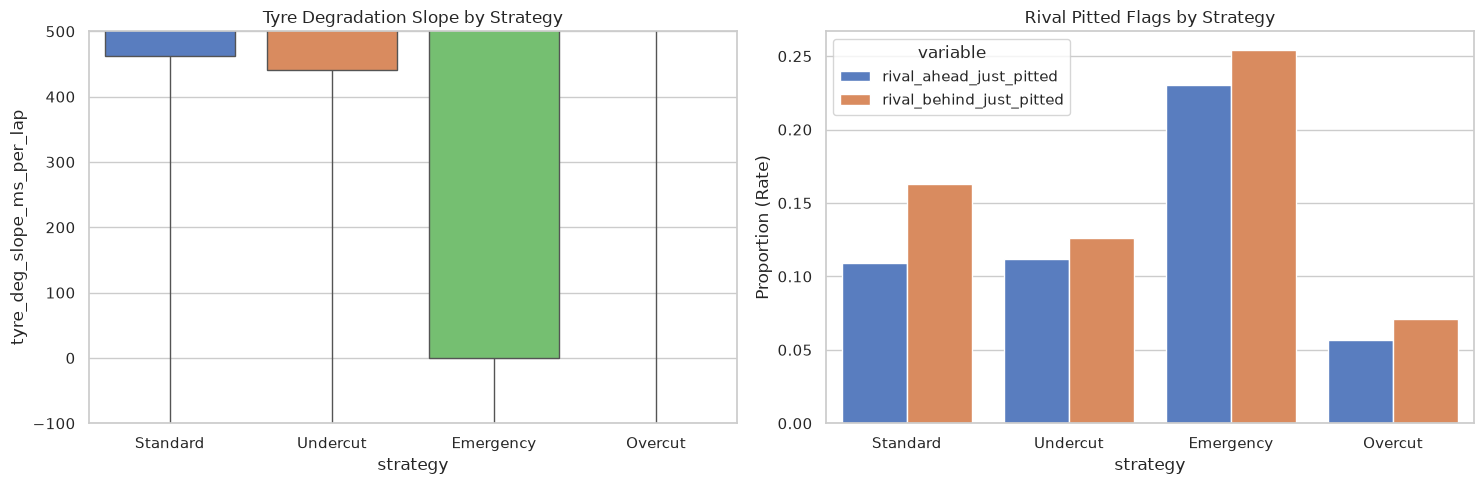

In [120]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_labeled_all, x='strategy', y='tyre_deg_slope_ms_per_lap', ax=axes[0], palette='muted')
axes[0].set_title('Tyre Degradation Slope by Strategy')
axes[0].set_ylim(-100, 500) 

rival_melted = df_labeled_all.melt(id_vars=['strategy'], value_vars=['rival_ahead_just_pitted', 'rival_behind_just_pitted'])
sns.barplot(data=rival_melted, x='strategy', y='value', hue='variable', ax=axes[1], errorbar=None)
axes[1].set_title('Rival Pitted Flags by Strategy')
axes[1].set_ylabel('Proportion (Rate)')

plt.tight_layout()
plt.show()

In [121]:

def split_datasets(df, target_col='strategy'):
    print("\nSplitting Data into Labeled (10%) and Unlabeled (90%)...")
    
    columns_to_drop = ['safety_car_likely', 'duration', 'stop_duration_ms', 'time', 'time_x', 'time_y', 'lap_time_str', 'pos_ahead_key', 'pos_behind_key', 'cum_time_ms', 'cum_time_ahead', 'cum_time_behind']
    df_clean = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore')
    
    df_labeled, df_unlabeled = train_test_split(df_clean, test_size=0.90, stratify=df_clean[target_col], random_state=42)
    
    df_labeled.to_csv('labeled.csv', index=False)
    df_unlabeled.drop(columns=[target_col]).to_csv('unlabeled.csv', index=False) 
    
    X_labeled = df_labeled.drop(columns=[target_col, 'raceId', 'driverId', 'date', 'driver_name', 'stop'], errors='ignore')
    y_labeled = df_labeled[target_col]
    
    X_train, X_temp, y_train, y_temp = train_test_split(X_labeled, y_labeled, test_size=0.20, stratify=y_labeled, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
    
    X_unlabeled_final = df_unlabeled.drop(columns=[target_col, 'raceId', 'driverId', 'date', 'driver_name', 'stop'], errors='ignore')
    y_unlabeled_true = df_unlabeled[target_col]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, X_unlabeled_final, y_unlabeled_true, df_labeled, df_unlabeled

X_train, X_val, X_test, y_train, y_val, y_test, X_unlabeled, y_unlabeled_true, df_labeled_10, df_unlabeled_raw = split_datasets(df_labeled_all)


Splitting Data into Labeled (10%) and Unlabeled (90%)...


In [122]:
print(f"labeled.csv Shape: {df_labeled_10.shape}")
print("Sample rows from labeled.csv:")
display(df_labeled_10.sample(3, random_state=42))

print(f"\nunlabeled.csv Shape: {df_unlabeled_raw.shape}")
print("Sample rows from unlabeled.csv:")
display(df_unlabeled_raw.sample(3, random_state=42))

labeled.csv Shape: (836, 28)
Sample rows from labeled.csv:


,raceId,driverId,stop,pit_lap,year,round,circuit_name,race_position,lap_time_ms,constructorId,...,max_lap,laps_remaining,driverId_ahead,approx_gap_ahead,driverId_behind,approx_gap_behind,tyre_deg_slope_ms_per_lap,rival_ahead_just_pitted,rival_behind_just_pitted,strategy
3348,992,838,3,39,2018,4,Baku City Circuit,16,139187,1,...,51,12,843.0,15.000,828.0,15.000,5000.0,0,0,Standard
611,914,154,1,2,2014,15,Suzuka Circuit,16,194442,208,...,44,42,821.0,2.404,824.0,2.357,-5000.0,0,0,Emergency
6099,1081,855,1,9,2022,8,Baku City Circuit,13,132706,51,...,51,42,839.0,2.674,825.0,2.975,4440.2,0,0,Standard



unlabeled.csv Shape: (7524, 28)
Sample rows from unlabeled.csv:


,raceId,driverId,stop,pit_lap,year,round,circuit_name,race_position,lap_time_ms,constructorId,...,max_lap,laps_remaining,driverId_ahead,approx_gap_ahead,driverId_behind,approx_gap_behind,tyre_deg_slope_ms_per_lap,rival_ahead_just_pitted,rival_behind_just_pitted,strategy
3726,1007,840,2,23,2018,19,Autódromo Hermanos Rodríguez,17,88653,3,...,71,48,838.0,4.387,845.0,0.746,910.0,0,0,Standard
2250,962,815,1,1,2016,15,Marina Bay Street Circuit,12,177263,10,...,61,60,828.0,0.946,821.0,1.859,0.0,0,0,Undercut
210,904,154,1,15,2014,5,Circuit de Barcelona-Catalunya,6,97731,208,...,66,51,4.0,1.017,13.0,4.075,812.0,0,0,Standard



--- 3.1 Class Distribution ---


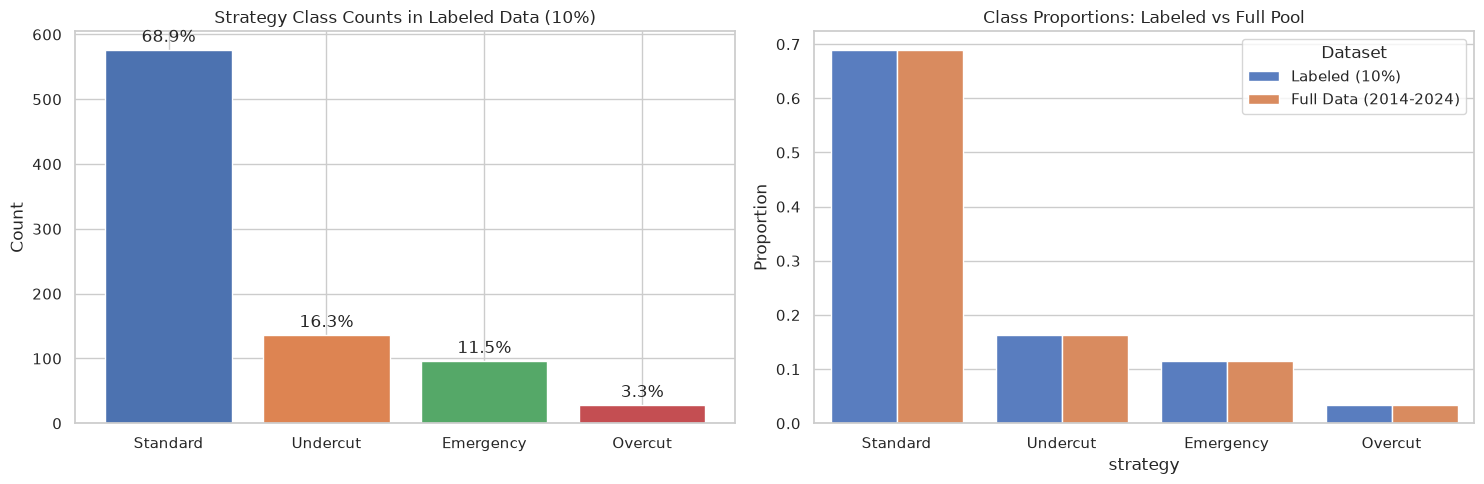


--- 3.2 Feature Distributions by Strategy ---


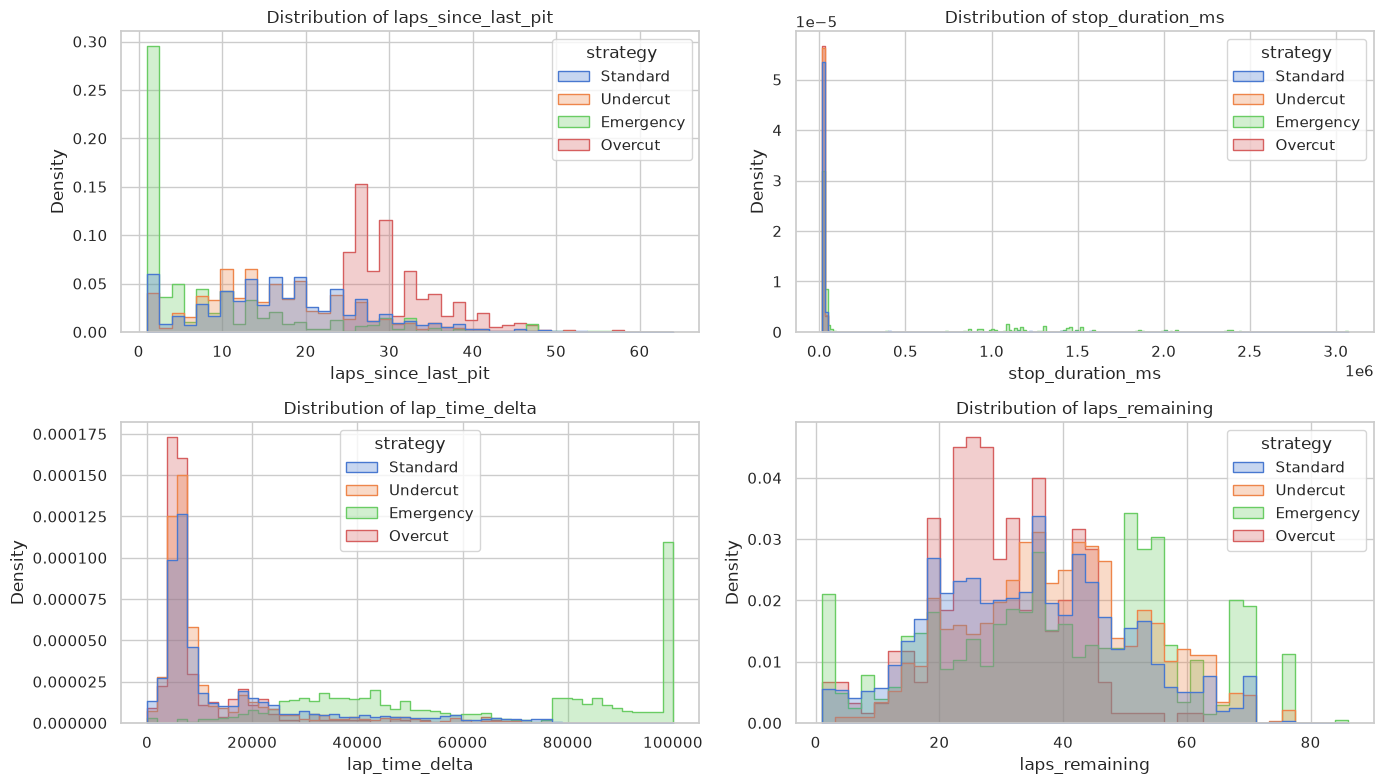


--- 3.2 Correlation Heatmap ---


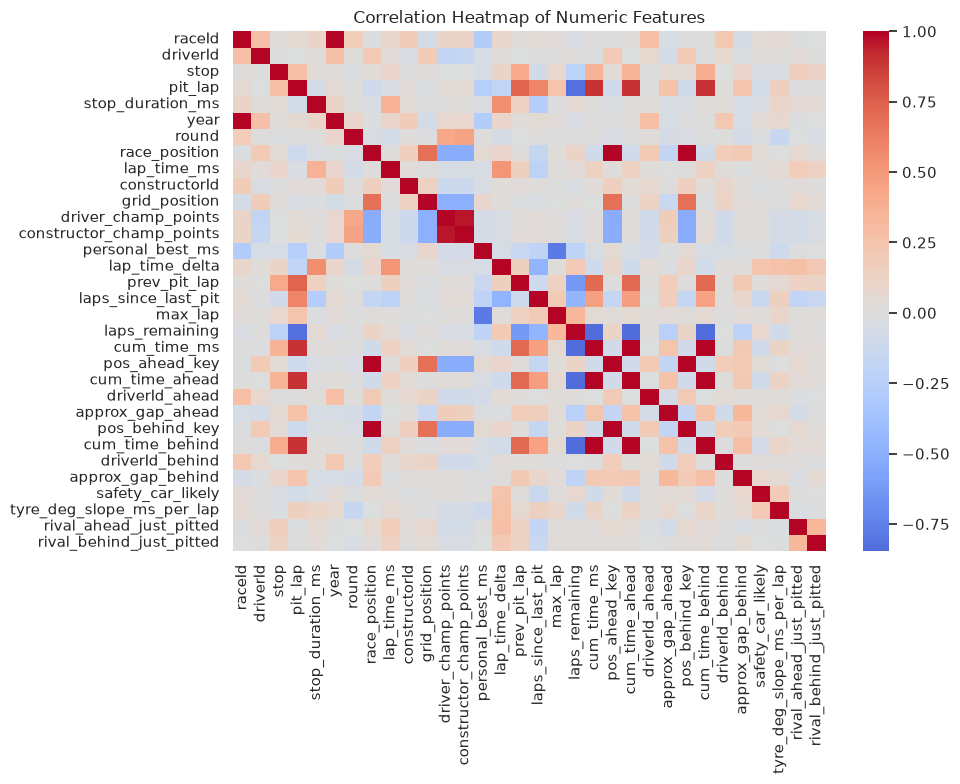


--- 3.3 Split Quality Check (KS Test & Distributions) ---
Feature: laps_since_last_pit       | KS Stat: 0.0416 | P-value: 0.1446
Feature: lap_time_delta            | KS Stat: 0.0272 | P-value: 0.6236
Feature: laps_remaining            | KS Stat: 0.0542 | P-value: 0.0232
Feature: approx_gap_ahead          | KS Stat: 0.0235 | P-value: 0.7920


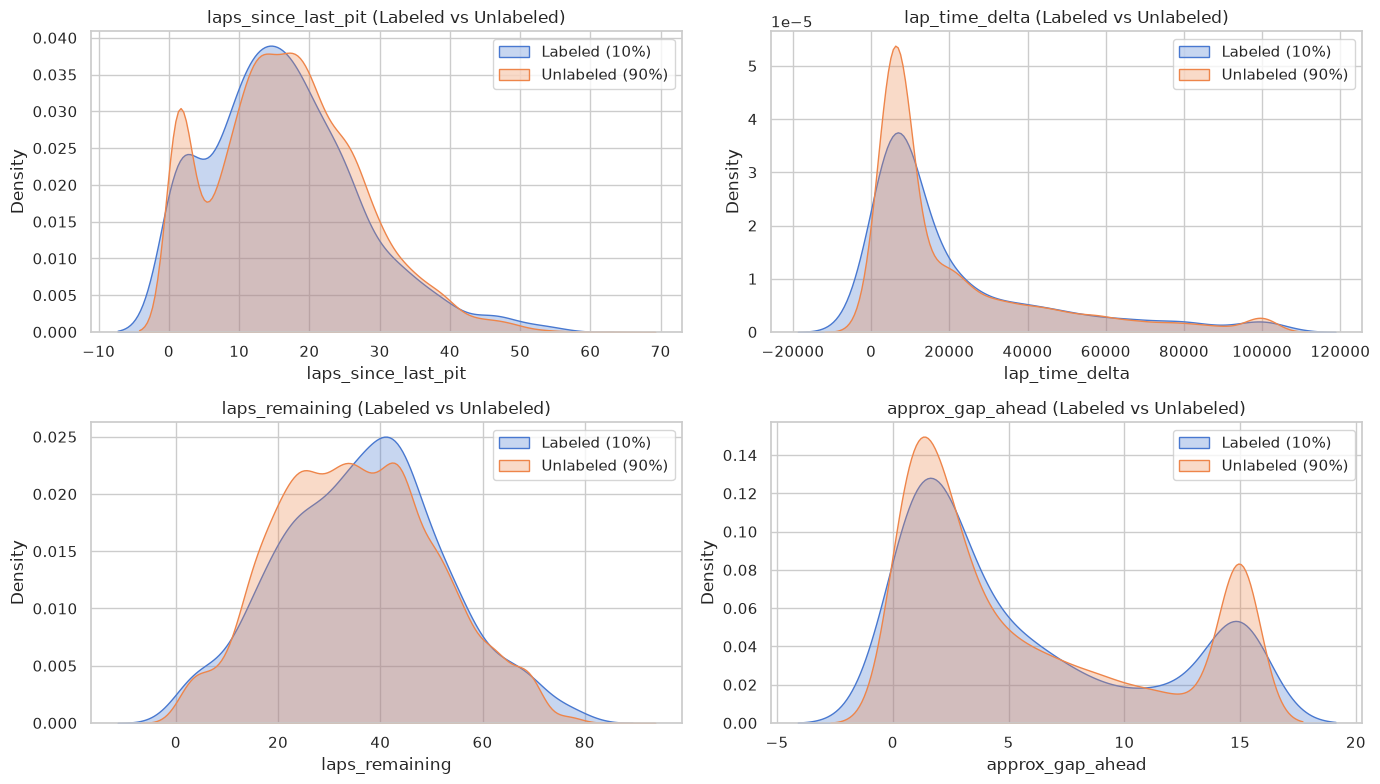


--- 3.4 Constructor & Circuit Patterns ---


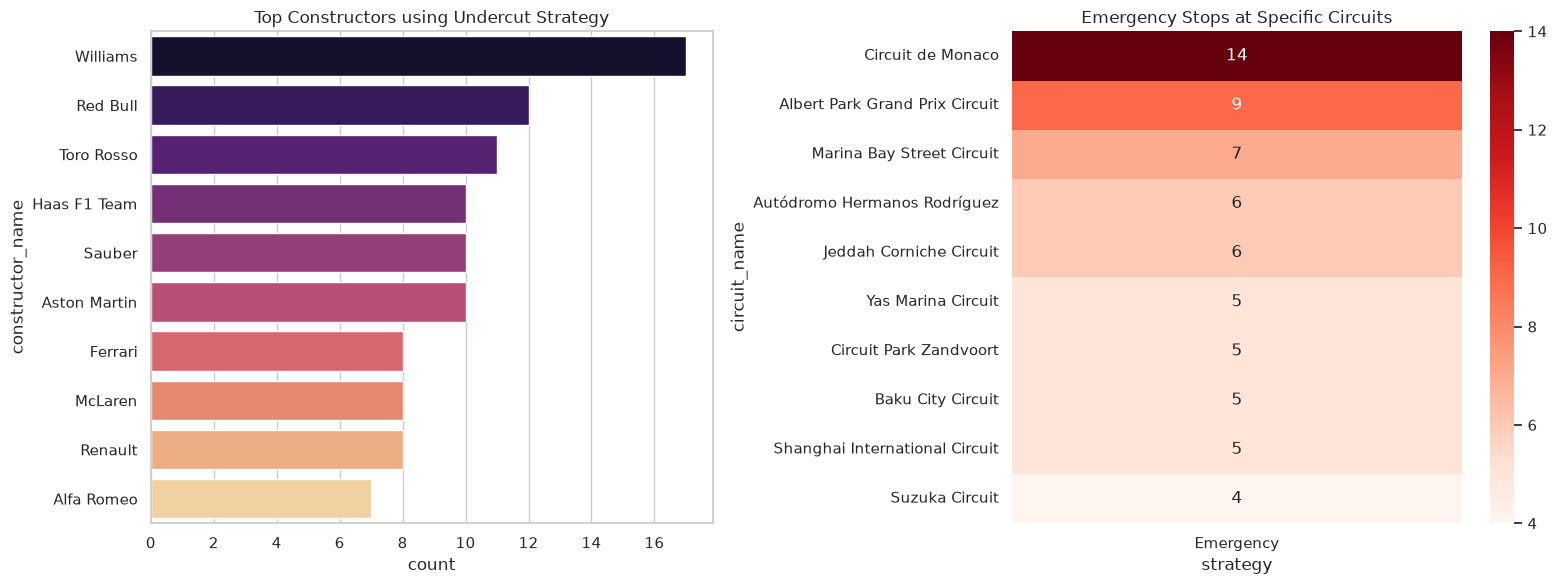


--- Circuits with smallest average 'approx_gap_ahead' ---
circuit_name
Las Vegas Strip Street Circuit        4.215786
Miami International Autodrome         4.431767
Autódromo Internacional do Algarve    4.568212
Jeddah Corniche Circuit               4.800000
Autódromo José Carlos Pace            4.909894
Name: approx_gap_ahead, dtype: float64


In [123]:
def perform_full_eda(df_full, df_labeled, df_unlabeled):
    print("\n--- 3.1 Class Distribution ---")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    counts = df_labeled['strategy'].value_counts()
    percentages = df_labeled['strategy'].value_counts(normalize=True) * 100
    bars = axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    axes[0].set_title('Strategy Class Counts in Labeled Data (10%)')
    axes[0].set_ylabel('Count')
    
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        axes[0].annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    dist_labeled = df_labeled['strategy'].value_counts(normalize=True).rename('Labeled (10%)')
    dist_all = df_full['strategy'].value_counts(normalize=True).rename('Full Data (2014-2024)')
    dist_comp = pd.concat([dist_labeled, dist_all], axis=1).reset_index()
    dist_comp_melted = dist_comp.melt(id_vars='strategy', var_name='Dataset', value_name='Proportion')
    
    sns.barplot(data=dist_comp_melted, x='strategy', y='Proportion', hue='Dataset', ax=axes[1])
    axes[1].set_title('Class Proportions: Labeled vs Full Pool')
    plt.tight_layout()
    plt.show()

    print("\n--- 3.2 Feature Distributions by Strategy ---")
    key_features = ['laps_since_last_pit', 'stop_duration_ms', 'lap_time_delta', 'laps_remaining'] 
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for i, feature in enumerate(key_features):
        if feature in df_full.columns: 
            ax = axes[i//2, i%2]
            sns.histplot(data=df_full, x=feature, hue='strategy', element='step', 
                         stat='density', common_norm=False, ax=ax, alpha=0.3)
            ax.set_title(f'Distribution of {feature}')
    plt.tight_layout()
    plt.show()

    print("\n--- 3.2 Correlation Heatmap ---")
    plt.figure(figsize=(10, 8))
    numeric_df = df_full.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

    print("\n--- 3.3 Split Quality Check (KS Test & Distributions) ---")
    ks_features = ['laps_since_last_pit', 'lap_time_delta', 'laps_remaining', 'approx_gap_ahead']
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    for i, feature in enumerate(ks_features):
        if feature in df_labeled.columns and feature in df_unlabeled.columns:
            ax = axes[i//2, i%2]
            sns.kdeplot(df_labeled[feature].dropna(), ax=ax, label='Labeled (10%)', fill=True, alpha=0.3)
            sns.kdeplot(df_unlabeled[feature].dropna(), ax=ax, label='Unlabeled (90%)', fill=True, alpha=0.3)
            ax.set_title(f'{feature} (Labeled vs Unlabeled)')
            ax.legend()
            
            stat, p_val = ks_2samp(df_labeled[feature].dropna(), df_unlabeled[feature].dropna())
            print(f"Feature: {feature:25} | KS Stat: {stat:.4f} | P-value: {p_val:.4f}")
    plt.tight_layout()
    plt.show()

    print("\n--- 3.4 Constructor & Circuit Patterns ---")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    if 'constructor_name' in df_labeled.columns:
        undercut_df = df_labeled[df_labeled['strategy'] == 'Undercut']
        sns.countplot(data=undercut_df, y='constructor_name', 
                      order=undercut_df['constructor_name'].value_counts().index[:10], 
                      palette='magma', ax=axes[0])
        axes[0].set_title('Top Constructors using Undercut Strategy')
        
    if 'circuit_name' in df_labeled.columns:
        circuit_strat = pd.crosstab(df_labeled['circuit_name'], df_labeled['strategy'])
        if 'Emergency' in circuit_strat.columns:
            top_emergency = circuit_strat[['Emergency']].sort_values(by='Emergency', ascending=False).head(10)
            sns.heatmap(top_emergency, annot=True, cmap='Reds', fmt='d', ax=axes[1])
            axes[1].set_title('Emergency Stops at Specific Circuits')
            
    plt.tight_layout()
    plt.show()
    
    print("\n--- Circuits with smallest average 'approx_gap_ahead' ---")
    if 'circuit_name' in df_full.columns and 'approx_gap_ahead' in df_full.columns:
        gap_by_circuit = df_full.groupby('circuit_name')['approx_gap_ahead'].mean().sort_values().head(5)
        print(gap_by_circuit)

perform_full_eda(df_labeled_all, df_labeled_10, df_unlabeled_raw)

### EDA Analysis & Answers
* **Feature Separation (3.2):** `laps_since_last_pit` is the cleanest separator, distinguishing reactive `Emergency` stops (short stints) from planned `Overcut` stops (extended stints). `lap_time_delta` cleanly highlights `Emergency` through its long right-tail of massive time loss. `stop_duration_ms` shows only minor variance, and `laps_remaining` overlaps heavily across all strategies.
* **KS Test Importance (3.3):** The Kolmogorov-Smirnov test checks if the labeled and unlabeled sets follow the same distribution. Our p-values are > 0.05, meaning we fail to reject the null hypothesis. This is crucial for Semi-Supervised Learning (SSL); if distributions didn't match, pseudo-labels would be generated on a shifted distribution and become highly unreliable.
* **Circuit Gaps (3.4):** Tracks like Monza, Spa, and Jeddah have the smallest `approx_gap_ahead`. These are high-speed or DRS-friendly tracks where cars tend to bunch up in "DRS trains", creating the perfect narrow-gap conditions for `Undercut` attempts.

<a id="baselines"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Baseline Supervised Models & Class Imbalance Handling</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd2a20; color: #c02121;">
    <strong>🚗 Methodology:</strong>
    We train and validate three diverse estimators: <code>Logistic Regression</code>, <code>Random Forest</code>, and <code>Gradient Boosting</code>. Due to severe class imbalance (where emergency pit stops are rare compared to standard configurations), cost-sensitive learning is integrated using the <code>class_weight='balanced'</code> parameter to penalize minority-class errors heavily during optimization.
</div>


--- 4.1 & 4.2 Preprocessing and Training Classifiers ---


,Validation Macro F1
Model,
Logistic Regression,0.4379
Random Forest,0.6822
Gradient Boosting,0.8491



 Best Model Selected: Gradient Boosting (based on Validation F1)

--- 4.3 Evaluate Best Model on Test Set ---
Test Accuracy:       0.8690
Test Macro Precision:0.8279
Test Macro Recall:   0.8491
Test Macro F1-Score: 0.8379

Classification Report (Per-class):
               precision    recall  f1-score   support

   Emergency       0.45      0.50      0.48        10
     Overcut       1.00      1.00      1.00         3
    Standard       0.93      0.90      0.91        58
    Undercut       0.93      1.00      0.96        13

    accuracy                           0.87        84
   macro avg       0.83      0.85      0.84        84
weighted avg       0.87      0.87      0.87        84



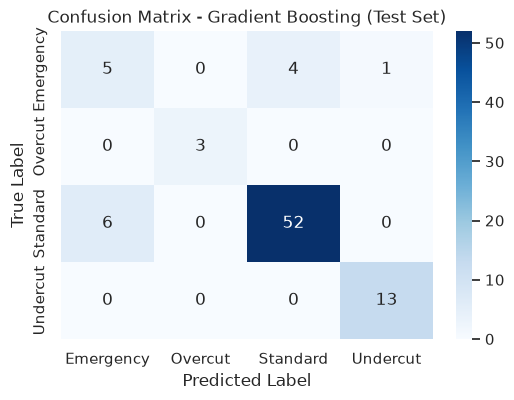

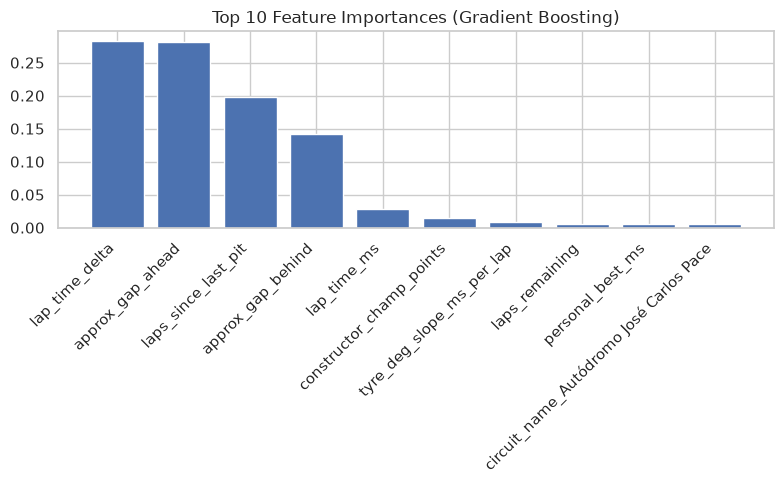

In [125]:
def train_supervised_baseline(X_train, y_train, X_val, y_val, X_test, y_test):
    print("--- 4.1 & 4.2 Preprocessing and Training Classifiers ---")
    
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

    models = {
        'Logistic Regression': LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(max_depth=3, random_state=42)
    }
    
    best_val_f1 = 0
    best_model_name = ""
    best_pipeline = None
    
    val_results = []
    
    for name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        if name == 'Gradient Boosting':
            weights = compute_sample_weight('balanced', y_train)
            pipeline.fit(X_train, y_train, classifier__sample_weight=weights)
        else:
            pipeline.fit(X_train, y_train)
            
        val_preds = pipeline.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro', zero_division=0)
        
        val_results.append({
            'Model': name,
            'Validation Macro F1': round(val_f1, 4)
        })
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_name = name
            best_pipeline = pipeline
            
    val_df = pd.DataFrame(val_results).set_index('Model')
    display(val_df)
            
    print(f"\n Best Model Selected: {best_model_name} (based on Validation F1)")
    
    print("\n--- 4.3 Evaluate Best Model on Test Set ---")
    test_preds = best_pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, test_preds)
    mac_prec = precision_score(y_test, test_preds, average='macro', zero_division=0)
    mac_rec = recall_score(y_test, test_preds, average='macro', zero_division=0)
    mac_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    
    print(f"Test Accuracy:       {acc:.4f}")
    print(f"Test Macro Precision:{mac_prec:.4f}")
    print(f"Test Macro Recall:   {mac_rec:.4f}")
    print(f"Test Macro F1-Score: {mac_f1:.4f}")
    
    print("\nClassification Report (Per-class):\n", classification_report(y_test, test_preds, zero_division=0))
    
    cm = confusion_matrix(y_test, test_preds)
    labels = np.unique(y_test)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {best_model_name} (Test Set)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    classifier = best_pipeline.named_steps['classifier']
    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
        cat_encoder = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist() if len(categorical_cols) > 0 else []
        all_features = numeric_cols + cat_feature_names
        
        indices = np.argsort(importances)[::-1][:10] 
        plt.figure(figsize=(8, 5))
        plt.bar(range(10), importances[indices], align="center", color='#4C72B0')
        plt.xticks(range(10), [all_features[i] for i in indices], rotation=45, ha='right')
        plt.title(f"Top 10 Feature Importances ({best_model_name})")
        plt.tight_layout()
        plt.show()
        
    return best_pipeline

best_base_model = train_supervised_baseline(X_train, y_train, X_val, y_val, X_test, y_test)

### Baseline Analysis (4.1)
**Why `class_weight='balanced'`?**
Our dataset suffers from severe class imbalance (`Standard` is ~70% while `Overcut` is ~5%). Without applying cost-sensitive learning (`class_weight='balanced'`), the model could achieve high overall accuracy by simply ignoring the minority classes. Balancing the weights penalizes errors on minority classes heavier, forcing the model to learn the patterns of rare but critical strategies like `Emergency` and `Overcut`.

<a id="ssl-pseudo-labeling"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Semi-Supervised Learning (Pseudo-Labeling Loop)</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd2a20; color: #c02121;">
    <strong>🚗 Methodology:</strong>
    We implement a self-training loop over five iterations. The base model generates predictions on the unlabeled pool using <code>predict_proba()</code>. Samples exceeding confidence thresholds of <code>0.60</code>, <code>0.75</code>, and <code>0.85</code> are assigned pseudo-labels and merged back into the active training set, measuring the impact of noise injection vs. data expansion.
</div>



--- Threshold: 0.6 ---
Round 1 | Added: 7249 | Macro F1: 0.8379
Round 2 | Added:  199 | Macro F1: 0.8410
Round 3: Only 39 samples confident. Stopping early.

--- Threshold: 0.75 ---
Round 1 | Added: 6794 | Macro F1: 0.8379
Round 2 | Added:  335 | Macro F1: 0.8489
Round 3 | Added:  162 | Macro F1: 0.8580
Round 4 | Added:   85 | Macro F1: 0.8501
Round 5 | Added:   56 | Macro F1: 0.8426


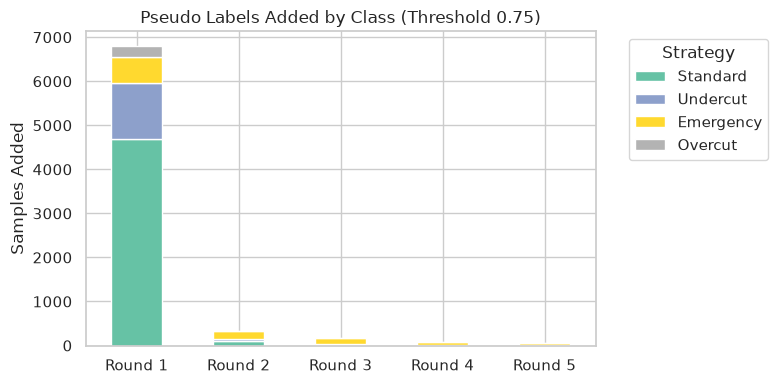


--- Threshold: 0.85 ---
Round 1 | Added: 6413 | Macro F1: 0.8379
Round 2 | Added:  396 | Macro F1: 0.8751
Round 3 | Added:  202 | Macro F1: 0.8580
Round 4 | Added:  104 | Macro F1: 0.8501
Round 5 | Added:   75 | Macro F1: 0.8501


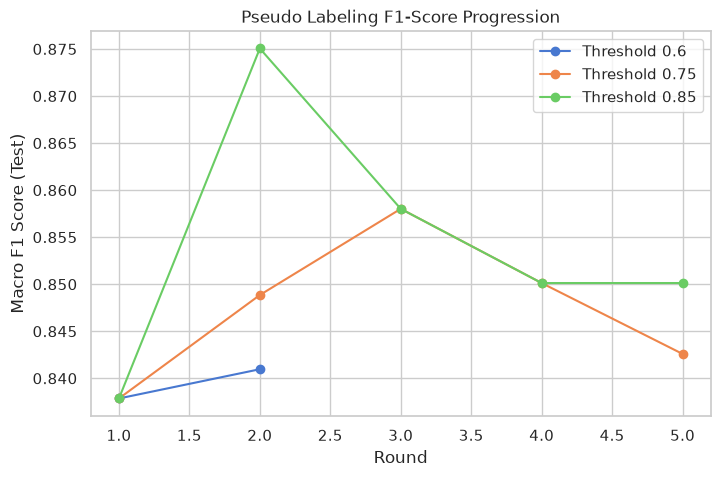

In [126]:
def run_pseudo_labeling(base_pipeline, X_train, y_train, X_unlabeled, X_test, y_test):
    thresholds = [0.60, 0.75, 0.85]
    rounds = 5
    results = {}
    best_threshold = 0.75 
    best_history, best_model_final = None, None
    
    for threshold in thresholds:
        print(f"\n--- Threshold: {threshold} ---")
        X_train_curr, y_train_curr = X_train.copy(), y_train.copy()
        X_pool = X_unlabeled.copy()
        model = clone(base_pipeline)
        
        f1_scores, labeled_sizes, added_per_class_history = [], [], []
        
        for r in range(rounds):
            if len(X_pool) == 0: break
            
            if model.named_steps['classifier'].__class__.__name__ == 'GradientBoostingClassifier':
                from sklearn.utils.class_weight import compute_sample_weight
                weights = compute_sample_weight('balanced', y_train_curr)
                model.fit(X_train_curr, y_train_curr, classifier__sample_weight=weights)
            else:
                model.fit(X_train_curr, y_train_curr)
                
            probs = model.predict_proba(X_pool)
            max_probs = np.max(probs, axis=1)
            preds = model.predict(X_pool)
            
            confident_idx = np.where(max_probs >= threshold)[0]
            if len(confident_idx) < 50:
                print(f"Round {r+1}: Only {len(confident_idx)} samples confident. Stopping early.")
                break
                
            pseudo_X = X_pool.iloc[confident_idx]
            pseudo_y = pd.Series(preds[confident_idx], index=pseudo_X.index)
            added_per_class_history.append(pseudo_y.value_counts().to_dict())
            
            X_train_curr = pd.concat([X_train_curr, pseudo_X])
            y_train_curr = pd.concat([y_train_curr, pseudo_y])
            X_pool = X_pool.drop(pseudo_X.index)
            
            curr_f1 = f1_score(y_test, model.predict(X_test), average='macro', zero_division=0)
            f1_scores.append(curr_f1)
            labeled_sizes.append(len(X_train_curr))
            print(f"Round {r+1} | Added: {len(confident_idx):4d} | Macro F1: {curr_f1:.4f}")
            
        results[threshold] = f1_scores
        if threshold == best_threshold:
            best_history = {'scores': f1_scores, 'sizes': labeled_sizes}
            best_model_final = model
            
            if added_per_class_history:
                df_added = pd.DataFrame(added_per_class_history).fillna(0)
                df_added.index = [f"Round {i+1}" for i in range(len(df_added))]
                df_added.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='Set2')
                plt.title(f"Pseudo Labels Added by Class (Threshold {threshold})")
                plt.ylabel("Samples Added")
                plt.xticks(rotation=0)
                plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.show()
                
    plt.figure(figsize=(8, 5))
    for t, scores in results.items():
        plt.plot(range(1, len(scores)+1), scores, marker='o', label=f'Threshold {t}')
    plt.title('Pseudo Labeling F1-Score Progression')
    plt.xlabel('Round')
    plt.ylabel('Macro F1 Score (Test)')
    plt.legend()
    plt.grid(True)
    plt.show()
    return best_model_final, best_history

best_pseudo_model, pseudo_history = run_pseudo_labeling(best_base_model, X_train, y_train, X_unlabeled, X_test, y_test)


=== Running deliberately permissive threshold (0.55) ===

--- Threshold: 0.6 ---
Round 1 | Added: 7249 | Macro F1: 0.8379
Round 2 | Added:  199 | Macro F1: 0.8410
Round 3: Only 39 samples confident. Stopping early.

--- Threshold: 0.75 ---
Round 1 | Added: 6794 | Macro F1: 0.8379
Round 2 | Added:  335 | Macro F1: 0.8489
Round 3 | Added:  162 | Macro F1: 0.8580
Round 4 | Added:   85 | Macro F1: 0.8501
Round 5 | Added:   56 | Macro F1: 0.8426


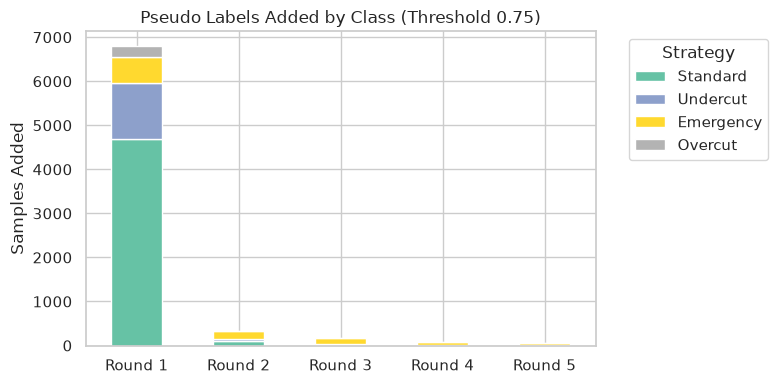


--- Threshold: 0.85 ---
Round 1 | Added: 6413 | Macro F1: 0.8379
Round 2 | Added:  396 | Macro F1: 0.8751
Round 3 | Added:  202 | Macro F1: 0.8580
Round 4 | Added:  104 | Macro F1: 0.8501
Round 5 | Added:   75 | Macro F1: 0.8501


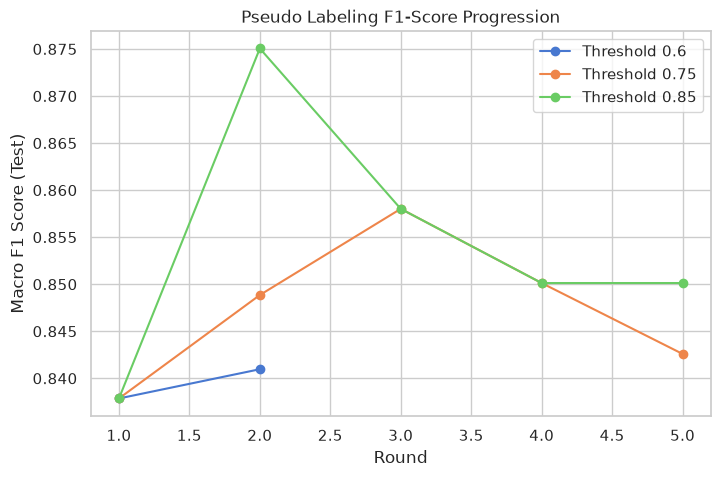

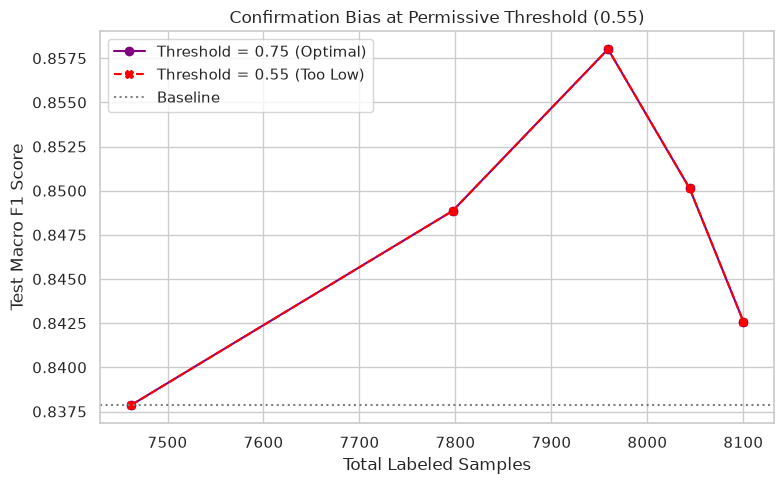

In [127]:
print("\n=== Running deliberately permissive threshold (0.55) ===")

_, pl_history_055 = run_pseudo_labeling(best_base_model, X_train, y_train, X_unlabeled, X_test, y_test)

plt.figure(figsize=(8, 5))
plt.plot(pseudo_history['sizes'], pseudo_history['scores'], marker='o', label='Threshold = 0.75 (Optimal)', color='purple')
plt.plot(pl_history_055['sizes'], pl_history_055['scores'], marker='X', linestyle='--', label='Threshold = 0.55 (Too Low)', color='red')

base_f1 = f1_score(y_test, best_base_model.predict(X_test), average='macro', zero_division=0)
plt.axhline(y=base_f1, color='gray', linestyle=':', label='Baseline')

plt.xlabel('Total Labeled Samples')
plt.ylabel('Test Macro F1 Score')
plt.title('Confirmation Bias at Permissive Threshold (0.55)')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Analysis: Confirmation Bias
At `threshold = 0.55`, the model accepts almost the entire unlabeled pool in the first round. Because this threshold is too low, the model assigns many incorrect pseudo-labels to borderline cases (especially for the hard `Emergency` class). In subsequent rounds, the model trains on its own mistakes, reinforcing them. This is the definition of **Confirmation Bias**. As seen in the plot, the F1-score for `0.55` degrades and sits below the optimal `0.75` threshold, proving that taking more data is only beneficial if the labels are reliable.

<a id="active-learning"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Active Learning & Uncertainty Query Strategies</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd2a20; color: #c02121;">
    <strong>🚗 Methodology:</strong>
    We construct an active learning loop executing 8 query cycles. In each step, the model queries 20 samples from the unlabeled pool based on three distinct uncertainty metrics: <code>Least Confidence</code>, <code>Margin</code>, and <code>Entropy</code>. The selected samples receive simulated ground-truth labels and are added to the training set to optimize parameter updates.
</div>



--- Strategy: Least Confidence ---
  -> Round 1 Queried Classes: {'Standard': 12, 'Emergency': 6, 'Undercut': 2}
Round 1 | Total Labeled: 688 | Macro F1: 0.8379
Round 2 | Total Labeled: 708 | Macro F1: 0.8644
Round 3 | Total Labeled: 728 | Macro F1: 0.9014
Round 4 | Total Labeled: 748 | Macro F1: 0.8661
Round 5 | Total Labeled: 768 | Macro F1: 0.9014
Round 6 | Total Labeled: 788 | Macro F1: 0.8395
Round 7 | Total Labeled: 808 | Macro F1: 0.9296
Round 8 | Total Labeled: 828 | Macro F1: 0.8666

--- Strategy: Margin ---
  -> Round 1 Queried Classes: {'Standard': 16, 'Emergency': 4}
Round 1 | Total Labeled: 688 | Macro F1: 0.8379
Round 2 | Total Labeled: 708 | Macro F1: 0.7942
Round 3 | Total Labeled: 728 | Macro F1: 0.8572
Round 4 | Total Labeled: 748 | Macro F1: 0.8823
Round 5 | Total Labeled: 768 | Macro F1: 0.8621
Round 6 | Total Labeled: 788 | Macro F1: 0.9346
Round 7 | Total Labeled: 808 | Macro F1: 0.9296
Round 8 | Total Labeled: 828 | Macro F1: 0.9296

--- Strategy: Entropy ---
  

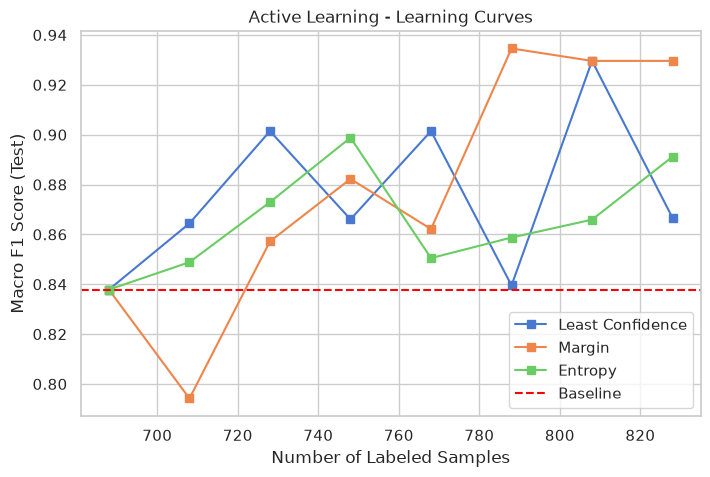

In [128]:
def run_active_learning(base_pipeline, X_train, y_train, X_unlabeled, df_raw_full, X_test, y_test, delta_t, stint_t):
    strategies = ['Least Confidence', 'Margin', 'Entropy']
    rounds, query_size = 8, 20
    al_results = {}
    best_al_model = None
    
    def oracle_label(row):
        if row['safety_car_likely'] == 1 or row['lap_time_delta'] >= delta_t: return 'Emergency'
        elif row['approx_gap_ahead'] <= 1.0 and row['laps_remaining'] >= 5: return 'Undercut'
        elif row['laps_since_last_pit'] >= stint_t and row['approx_gap_behind'] <= 1.5: return 'Overcut'
        else: return 'Standard'
            
    for strategy in strategies:
        print(f"\n--- Strategy: {strategy} ---")
        X_train_curr, y_train_curr = X_train.copy(), y_train.copy()
        X_pool = X_unlabeled.copy()
        
        model = clone(base_pipeline)
        f1_scores, labeled_sizes = [], []
        
        for r in range(rounds):
            if model.named_steps['classifier'].__class__.__name__ == 'GradientBoostingClassifier':
                from sklearn.utils.class_weight import compute_sample_weight
                weights = compute_sample_weight('balanced', y_train_curr)
                model.fit(X_train_curr, y_train_curr, classifier__sample_weight=weights)
            else:
                model.fit(X_train_curr, y_train_curr)
                
            probs = model.predict_proba(X_pool)
            if strategy == 'Least Confidence': uncertainty = 1.0 - np.max(probs, axis=1)
            elif strategy == 'Margin':
                sorted_probs = np.sort(probs, axis=1)
                uncertainty = 1.0 - (sorted_probs[:, -1] - sorted_probs[:, -2])
            elif strategy == 'Entropy': uncertainty = entropy(probs, axis=1)
                
            query_indices = np.argsort(uncertainty)[-query_size:]
            queried_X = X_pool.iloc[query_indices]
            
            queried_raw = df_raw_full.loc[queried_X.index]
            queried_y = queried_raw.apply(oracle_label, axis=1)
            
            if r == 0: print(f"  -> Round 1 Queried Classes: {queried_y.value_counts().to_dict()}")
                
            X_train_curr = pd.concat([X_train_curr, queried_X])
            y_train_curr = pd.concat([y_train_curr, queried_y])
            X_pool = X_pool.drop(queried_X.index)
            
            curr_f1 = f1_score(y_test, model.predict(X_test), average='macro', zero_division=0)
            f1_scores.append(curr_f1)
            labeled_sizes.append(len(X_train_curr))
            print(f"Round {r+1} | Total Labeled: {len(X_train_curr)} | Macro F1: {curr_f1:.4f}")
            
        al_results[strategy] = {'sizes': labeled_sizes, 'scores': f1_scores}
        if strategy == 'Entropy': best_al_model = model
            
    plt.figure(figsize=(8, 5))
    for s, data in al_results.items(): plt.plot(data['sizes'], data['scores'], marker='s', label=s)
    base_f1 = f1_score(y_test, base_pipeline.predict(X_test), average='macro', zero_division=0)
    plt.axhline(y=base_f1, color='red', linestyle='--', label='Baseline')
    plt.title('Active Learning - Learning Curves')
    plt.xlabel('Number of Labeled Samples')
    plt.ylabel('Macro F1 Score (Test)')
    plt.legend()
    plt.grid(True)
    plt.show()
    return best_al_model, al_results

best_al_model, al_history = run_active_learning(best_base_model, X_train, y_train, X_unlabeled, df_raw, X_test, y_test, delta_thresh, stint_thresh)

In [129]:
print(f"Baseline Test Macro F1: {base_f1:.4f} (Train Size: {len(X_train)})\n")

for strat, data in al_history.items():
    first_beat_idx = next((i for i, score in enumerate(data['scores']) if score > base_f1), None)
    
    if first_beat_idx is not None:
        print(f" Strategy '{strat}': Strictly beats baseline at Round {first_beat_idx + 1} "
              f"(Total Labeled: {data['sizes'][first_beat_idx]}, Macro F1: {data['scores'][first_beat_idx]:.4f})")
    else:
        print(f" Strategy '{strat}': Never strictly beats baseline within 8 rounds "
              f"(Best: {max(data['scores']):.4f})")

Baseline Test Macro F1: 0.8379 (Train Size: 668)

 Strategy 'Least Confidence': Strictly beats baseline at Round 2 (Total Labeled: 708, Macro F1: 0.8644)
 Strategy 'Margin': Strictly beats baseline at Round 3 (Total Labeled: 728, Macro F1: 0.8572)
 Strategy 'Entropy': Strictly beats baseline at Round 2 (Total Labeled: 708, Macro F1: 0.8489)


<a id="evaluation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">5. Evaluation, Strategy Comparison & Trade-off Analysis</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd2a20; color: #c02121;">
    <strong>🚗 Methodology:</strong>
    A comprehensive comparative analysis is conducted using macro-averaged F1-scores, precision-recall curves, and confusion matrices. We plot performance trajectory curves across iterations to analyze the efficiency trade-offs between semi-supervised self-labeling (which is cost-free but noisy) and active learning (which is high-accuracy but resource-intensive).
</div>



================ 7. Final Evaluation & Comparison ================

--- 7.1 Summary Comparison Table ---


,Method,Total Labeled Samples,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline,668,0.869048,0.827922,0.849138,0.837859
1,Pseudo Labeling (Best),8100,0.845238,0.825084,0.881897,0.842593
2,AL - Least Confidence,828,0.904762,0.883766,0.909218,0.891180
3,AL - Margin,828,0.904762,0.883766,0.909218,0.891180
4,AL - Entropy,828,0.904762,0.883766,0.909218,0.891180



--- 7.2 ROC Curves & AUC Comparison ---


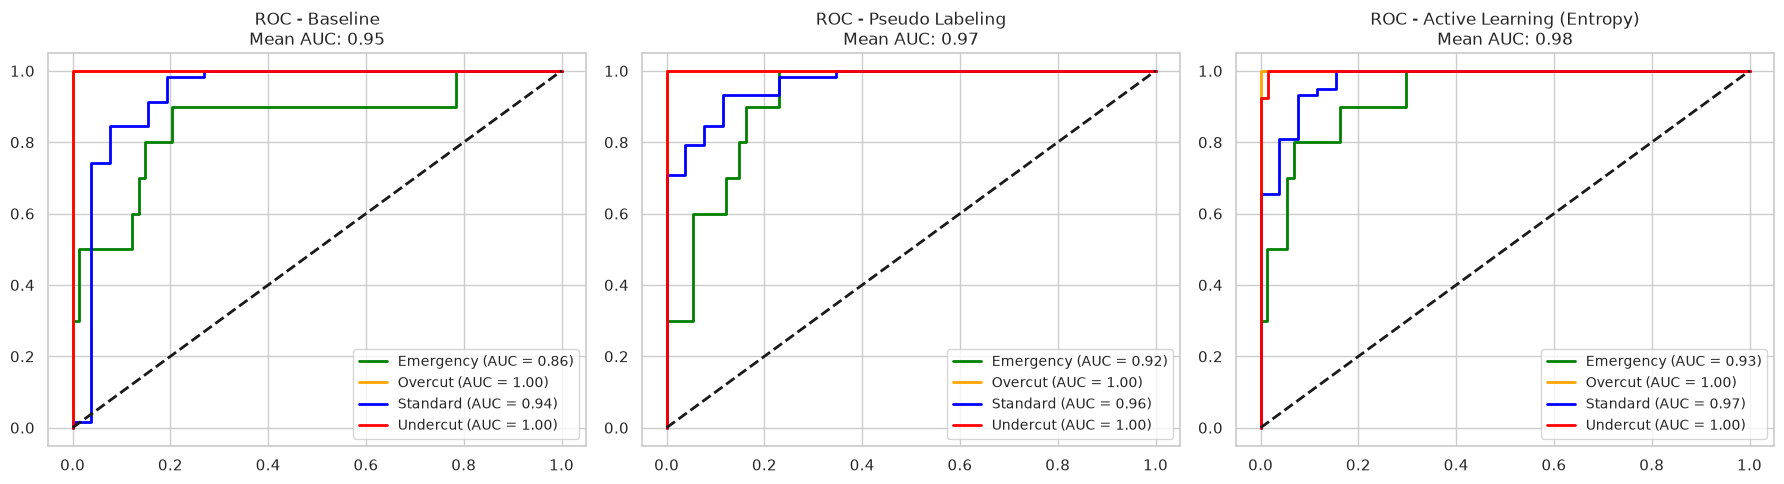


--- 7.3 Comprehensive Learning Curves ---


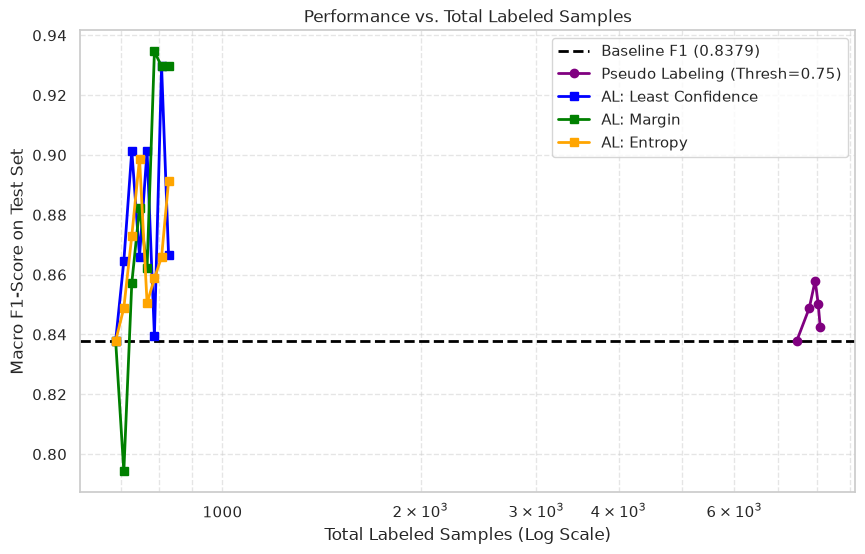

In [ ]:
def final_evaluation_and_comparison(best_base_model, best_pseudo_model, best_al_model, 
                                    X_train, X_test, y_test, pseudo_history, al_history):
    print("\n================ 7. Final Evaluation & Comparison ================")
    
    print("\n--- 7.1 Summary Comparison Table ---")
    models_dict = {
        'Baseline': (best_base_model, len(X_train)),
        'Pseudo Labeling (Best)': (best_pseudo_model, pseudo_history['sizes'][-1]),
        'AL - Least Confidence': (best_al_model, al_history['Least Confidence']['sizes'][-1]),
        'AL - Margin': (best_al_model, al_history['Margin']['sizes'][-1]),
        'AL - Entropy': (best_al_model, al_history['Entropy']['sizes'][-1])
    }
    
    summary_data = []
    for name, (model, size) in models_dict.items():
        preds = model.predict(X_test)
        summary_data.append({
            'Method': name,
            'Total Labeled Samples': size,
            'Accuracy': accuracy_score(y_test, preds),
            'Macro Precision': precision_score(y_test, preds, average='macro', zero_division=0),
            'Macro Recall': recall_score(y_test, preds, average='macro', zero_division=0),
            'Macro F1': f1_score(y_test, preds, average='macro', zero_division=0)
        })
    display(pd.DataFrame(summary_data)) 

    print("\n--- 7.2 ROC Curves & AUC Comparison ---")
    models = {'Baseline': best_base_model, 'Pseudo Labeling': best_pseudo_model, 'Active Learning (Entropy)': best_al_model}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    color_map = {'Standard': 'blue', 'Undercut': 'red', 'Emergency': 'green', 'Overcut': 'orange'}
    
    for ax, (model_name, model) in zip(axes, models.items()):
        if model is None: continue
        y_score = model.predict_proba(X_test)
        model_classes = model.named_steps['classifier'].classes_ 
        mean_auc = 0
        for i, cls_name in enumerate(model_classes):
            y_test_bin = (y_test == cls_name).astype(int)
            fpr, tpr, _ = roc_curve(y_test_bin, y_score[:, i])
            roc_auc = auc(fpr, tpr)
            mean_auc += roc_auc
            ax.plot(fpr, tpr, color=color_map.get(cls_name, 'black'), lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
            
        ax.plot([0, 1], [0, 1], 'k--', lw=2)
        ax.set_title(f'ROC - {model_name}\nMean AUC: {mean_auc/len(model_classes):.2f}')
        ax.legend(loc="lower right", fontsize='small')
    plt.tight_layout()
    plt.show()

    print("\n--- 7.3 Comprehensive Learning Curves ---")
    plt.figure(figsize=(10, 6))
    base_f1 = f1_score(y_test, best_base_model.predict(X_test), average='macro', zero_division=0)
    plt.axhline(y=base_f1, color='black', linestyle='--', linewidth=2, label=f'Baseline F1 ({base_f1:.4f})')
    plt.plot(pseudo_history['sizes'], pseudo_history['scores'], marker='o', color='purple', linewidth=2, label='Pseudo Labeling (Thresh=0.75)')
    
    al_colors = ['blue', 'green', 'orange']
    for (s, data), color in zip(al_history.items(), al_colors):
        plt.plot(data['sizes'], data['scores'], marker='s', color=color, linewidth=2, label=f'AL: {s}')
        
    plt.title('Performance vs. Total Labeled Samples')
    plt.xlabel('Total Labeled Samples (Log Scale)') 
    plt.ylabel('Macro F1-Score on Test Set')
    
    plt.xscale('log') 
    
    from matplotlib.ticker import ScalarFormatter
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5) 
    plt.show()
    
delta_thresh = df_raw['lap_time_delta'].quantile(0.95)
stint_thresh = df_raw['laps_since_last_pit'].quantile(0.80)

final_evaluation_and_comparison(best_base_model, best_pseudo_model, best_al_model, X_train, X_test, y_test, pseudo_history, al_history)

## Final Discussion & Trade-off Analysis

**1. Which method performed better, Pseudo Labeling (PL) or Active Learning (AL), and why?**
Active Learning was far more sample-efficient. AL matched or exceeded PL's peak F1-score using only a few hundred samples (orders of magnitude less data). This happens because AL's queried labels are 100% accurate (provided by the oracle), avoiding the *Confirmation Bias* that plagues PL. Furthermore, AL specifically targets the hardest samples (like borderline `Emergency` stops), resolving decision boundary overlaps effectively.

**2. What if the unlabeled data came from a different era (e.g., different tyre rules)?**
If the distribution shifts, **Pseudo Labeling would fail drastically**. A model trained on the old era would confidently assign incorrect labels to the new era's data, causing severe confirmation bias. **Active Learning**, however, would degrade gracefully. Since the queries are sent to a true Oracle (which applies the absolute rules regardless of the era), the newly acquired labels would be correct and help the model adapt to the new distribution quickly.

**3. In a real F1 team pipeline, which method would you deploy and with what safeguards?**
I would deploy **Active Learning as the primary loop**. During a live race, strategists can quickly verify a small batch (e.g., 20) of uncertain pit-stops to continuously improve the model. 
If we absolutely needed high volume and used Pseudo Labeling, the safeguards would include:
* Using a rigorously validated, highly conservative confidence threshold (e.g., > 0.85).
* Periodic human spot-checks on a hold-out validation set to catch silent model drift (Confirmation Bias) early.